# Loading data

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train = (x_train - mean) / (std + 1e-7)
x_test = (x_test - mean) / (std + 1e-7)


print(f"Träningsdata form: {x_train.shape}")
print(f"Antal klasser: {len(np.unique(y_train))}") 

Träningsdata form: (50000, 32, 32, 3)
Antal klasser: 100


# My own CNN

In [2]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(64, 64),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    # BLOCK 1: 2 st Conv-lager
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # BLOCK 2: 2 st Conv-lager
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # BLOCK 3: 2 st Conv-lager
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # KLASSIFICERING
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [3]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# Train model
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 543s 766ms/step - accuracy: 0.1231 - loss: 3.9052 - val_accuracy: 0.2254 - val_loss: 3.2432
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 505s 717ms/step - accuracy: 0.2325 - loss: 3.1348 - val_accuracy: 0.2876 - val_loss: 2.9004
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 488s 693ms/step - accuracy: 0.2955 - loss: 2.8048 - val_accuracy: 0.3606 - val_loss: 2.4650
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 486s 691ms/step - accuracy: 0.3412 - loss: 2.5907 - val_accuracy: 0.4018 - val_loss: 2.2858
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 486s 691ms/step - accuracy: 0.3694 - loss: 2.4483 - val_accuracy: 0.4184 - val_loss: 2.2472
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 487s 691ms/step - accuracy: 0.3970 - loss: 2.3210 - val_accuracy: 0.4570 - val_loss: 2.0359
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 495s 703ms/step - accuracy: 0.4172 - loss: 2.2201 - val_accuracy: 0.4632 - val_loss: 1.9698
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 532s 756ms/step - accuracy: 0.4346 -

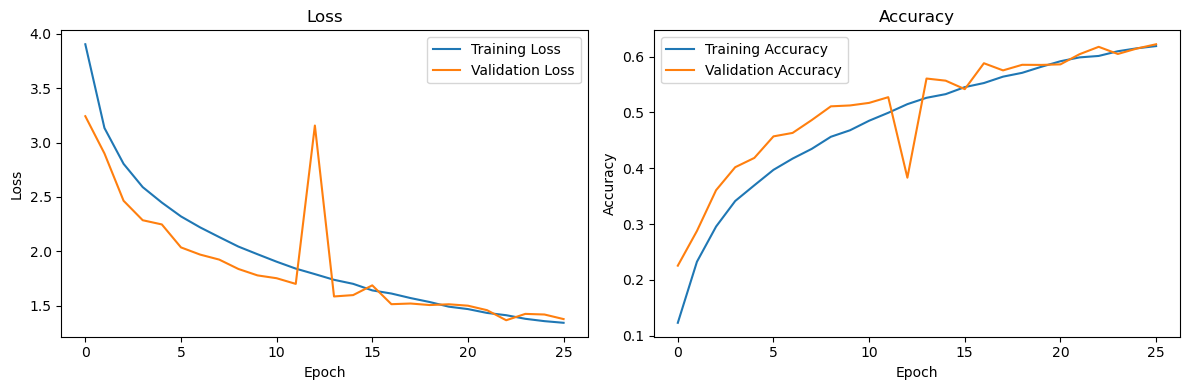

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
model.save('my_cifar100_model.keras')

In [6]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import pandas as pd
import numpy as np

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

TP = np.diag(cm).sum()
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TN = []
for i in range(len(cm)):
    temp = np.delete(cm, i, 0)
    temp = np.delete(temp, i, 1)
    TN.append(sum(sum(temp)))

results_data = {
    "Metric": ["Accuracy", "F1-score", "TP", "TN (Total)", "FP (Total)", "FN (Total)"],
    "Value": [f"{acc:.4f}", f"{f1:.4f}", int(TP), int(np.sum(TN)), int(np.sum(FP)), int(np.sum(FN))]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step
    Metric  Value
  Accuracy 0.6279
  F1-score 0.6266
        TP   6279
TN (Total) 986279
FP (Total)   3721
FN (Total)   3721


# ResNet-50

In [3]:
from tensorflow.keras import layers, models, optimizers

base_model = tf.keras.applications.ResNet50(
    include_top=False, 
    weights='imagenet',
    input_shape=(128, 128, 3)
)

base_model.trainable = False

model_resnet = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(128, 128),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')
])

model_resnet.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_resnet.fit(x_train, y_train, epochs=25, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 380s 268ms/step - accuracy: 0.0781 - loss: 4.1754 - val_accuracy: 0.1170 - val_loss: 3.8830
Epoch 2/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 361s 257ms/step - accuracy: 0.1196 - loss: 3.8479 - val_accuracy: 0.1114 - val_loss: 3.8688
Epoch 3/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 347s 247ms/step - accuracy: 0.1289 - loss: 3.7831 - val_accuracy: 0.1424 - val_loss: 3.7433
Epoch 4/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 369s 263ms/step - accuracy: 0.1314 - loss: 3.7787 - val_accuracy: 0.1502 - val_loss: 3.6872
Epoch 5/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 359s 255ms/step - accuracy: 0.1327 - loss: 3.7598 - val_accuracy: 0.1140 - val_loss: 3.9045
Epoch 6/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 344s 245ms/step - accuracy: 0.1322 - loss: 3.7702 - val_accuracy: 0.1332 - val_loss: 3.7182
Epoch 7/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 343s 244ms/step - accuracy: 0.1294 - loss: 3.7756 - val_accuracy: 0.1594 - val_loss: 3.6048
Epoch 8/25
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 386s 246ms/step - ac

KeyboardInterrupt: 

# VGG-19

# DenseNet-121

# EfficientNet